# Random Forest Regression – Outlier Clipping & NaN Imputation

**Goal:** Improve stress-test performance by fixing the data preprocessing,
not the model. Previous experiments proved that no hyperparameter tuning
could push stress-test R² above zero. Now we attack the root cause:
missing values filled with crude medians and extreme outliers that land
in wrong tree leaves.

**Three preprocessing strategies compared:**
1. **Baseline** — median imputation (what we used before)
2. **KNN Imputation** — fill NaN based on similar rows, not one global median
3. **KNN + Outlier Clipping** — also cap extreme values to the training range

**Workflow:**
1. Load data, train/test split
2. Train the Random Forest (best baseline config)
3. Evaluate with median imputation (baseline)
4. Evaluate with KNN imputation
5. Evaluate with KNN imputation + outlier clipping
6. Compare all three approaches


## Step 1 – Imports

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

print("All imports successful.")


All imports successful.


## Step 2 – Load Data and Train/Test Split

In [9]:
df = pd.read_csv("meat_price_dataset.csv")

target_col = "price_eur_per_kg"
feature_cols = [c for c in df.columns if c != target_col]

X = df[feature_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
)

print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")


Train: 960 rows | Test: 240 rows


## Step 3 – Train the Random Forest

Using the best baseline configuration from previous experiments.


In [10]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=7,
    random_state=42,
    n_jobs=-1,
)

rf_model.fit(X_train, y_train)

# Internal test result
y_pred = rf_model.predict(X_test)
mae_test  = mean_absolute_error(y_test, y_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))
r2_test   = r2_score(y_test, y_pred)

print("=== Internal Test ===")
print(f"MAE:  {mae_test:.2f} EUR")
print(f"RMSE: {rmse_test:.2f} EUR")
print(f"R²:   {r2_test:.4f}")


=== Internal Test ===
MAE:  1.80 EUR
RMSE: 2.25 EUR
R²:   0.9249


## Step 4 – Load the Stress-Test Dataset

Let us first look at the raw data before any processing.


In [11]:
df_stress = pd.read_csv("meat_price_100_stress_test.csv")

print(f"Shape: {df_stress.shape}")
print(f"=== Missing Values ===")
print(df_stress.isnull().sum())
print(f"=== Stress-Test Stats ===")
print(df_stress.describe().round(2))


Shape: (100, 9)
=== Missing Values ===
meat_type             9
fat_content_pct      14
protein_pct          10
marbling_score       11
animal_age_months     8
storage_days          9
organic               9
cut_quality           7
price_eur_per_kg      9
dtype: int64
=== Stress-Test Stats ===
       meat_type  fat_content_pct  protein_pct  marbling_score  \
count      91.00            86.00        90.00           89.00   
mean        3.11            19.85        20.39            4.51   
std         1.45            11.31         2.85            2.55   
min         1.00             2.00        15.10            0.00   
25%         2.00            10.92        18.10            3.00   
50%         3.00            19.55        20.15            4.00   
75%         4.00            25.50        22.85            6.00   
max         5.00            58.50        25.00           12.00   

       animal_age_months  storage_days  organic  cut_quality  price_eur_per_kg  
count              92.00      

## Step 5 – Detect Outliers in the Stress-Test Data

An outlier is a value far outside the range the model was trained on.
If the training data has `fat_content_pct` between 5 and 35, but the
stress test has a row with 60, the model has never seen that value
and will likely make a bad prediction.

We compare the stress-test range to the training range for each feature.


In [12]:
print(f"{'Feature':<20} {'Train Min':>10} {'Train Max':>10} {'Stress Min':>10} {'Stress Max':>10} {'Outliers?':>10}")
print("-" * 72)

X_stress_raw = df_stress[feature_cols].copy()

for col in feature_cols:
    t_min = X_train[col].min()
    t_max = X_train[col].max()
    s_min = X_stress_raw[col].min()
    s_max = X_stress_raw[col].max()
    has_outlier = "YES" if (s_min < t_min or s_max > t_max) else "no"
    print(f"{col:<20} {t_min:>10.2f} {t_max:>10.2f} {s_min:>10.2f} {s_max:>10.2f} {has_outlier:>10}")


Feature               Train Min  Train Max Stress Min Stress Max  Outliers?
------------------------------------------------------------------------
meat_type                  1.00       5.00       1.00       5.00         no
fat_content_pct            2.00      35.00       2.00      58.50        YES
protein_pct               15.00      26.00      15.10      25.00         no
marbling_score             1.00      10.00       0.00      12.00        YES
animal_age_months          2.00      71.00       2.00     189.00        YES
storage_days               0.00      20.00       0.00      80.00        YES
organic                    0.00       1.00       0.00       1.00         no
cut_quality                1.00       5.00       1.00       5.00         no


---
## Strategy 1: Median Imputation (Baseline)

**How it works:** Every missing value gets replaced with the median of that
column from the training set. Simple and fast, but crude — it ignores
the relationships between features. A premium organic wagyu steak with
a missing `fat_content_pct` gets the same fill as a cheap supermarket cut.


In [13]:
X_stress = df_stress[feature_cols].copy()
y_stress = df_stress[target_col].copy()

# Median imputation
train_medians = X_train.median()
X_stress_median = X_stress.fillna(train_medians)

# Drop rows where target is NaN
valid_mask = y_stress.notna()
X_s1 = X_stress_median[valid_mask]
y_s1 = y_stress[valid_mask]

# Predict
y_pred_s1 = rf_model.predict(X_s1)
mae_s1  = mean_absolute_error(y_s1, y_pred_s1)
rmse_s1 = np.sqrt(mean_squared_error(y_s1, y_pred_s1))
r2_s1   = r2_score(y_s1, y_pred_s1)

print("=== Strategy 1: Median Imputation ===")
print(f"MAE:  {mae_s1:.2f} EUR")
print(f"RMSE: {rmse_s1:.2f} EUR")
print(f"R²:   {r2_s1:.4f}")
print(f"Rows: {len(y_s1)}")


=== Strategy 1: Median Imputation ===
MAE:  8.68 EUR
RMSE: 11.33 EUR
R²:   -0.3288
Rows: 91


---
## Strategy 2: KNN Imputation

**How it works:** For each row with a missing value, the KNN imputer finds
the k most similar rows (based on all non-missing features) and fills
the gap with the average of those neighbors' values.

**Why it is better:** A premium steak with missing fat content gets a fill
based on other premium steaks — not the global median of all meats.

**Important:** We `fit` the imputer on the training data only, then
`transform` the stress test. This prevents data leakage.


In [14]:
# Fit KNN imputer on training data
knn_imputer = KNNImputer(n_neighbors=5)
knn_imputer.fit(X_train)

# Transform stress test
X_stress_knn = pd.DataFrame(
    knn_imputer.transform(X_stress),
    columns=feature_cols,
    index=X_stress.index,
)

X_s2 = X_stress_knn[valid_mask]
y_s2 = y_stress[valid_mask]

# Predict
y_pred_s2 = rf_model.predict(X_s2)
mae_s2  = mean_absolute_error(y_s2, y_pred_s2)
rmse_s2 = np.sqrt(mean_squared_error(y_s2, y_pred_s2))
r2_s2   = r2_score(y_s2, y_pred_s2)

print("=== Strategy 2: KNN Imputation ===")
print(f"MAE:  {mae_s2:.2f} EUR")
print(f"RMSE: {rmse_s2:.2f} EUR")
print(f"R²:   {r2_s2:.4f}")
print(f"Rows: {len(y_s2)}")


=== Strategy 2: KNN Imputation ===
MAE:  8.64 EUR
RMSE: 11.12 EUR
R²:   -0.2806
Rows: 91


### What changed? Median vs KNN fills compared


In [15]:
# Show rows where imputation made a difference
nan_cols = X_stress.columns[X_stress.isnull().any()].tolist()

if nan_cols:
    compare = pd.DataFrame()
    for col in nan_cols:
        mask = X_stress[col].isnull()
        if mask.any():
            temp = pd.DataFrame({
                "Column": col,
                "Median Fill": X_stress_median.loc[mask, col].values,
                "KNN Fill":    X_stress_knn.loc[mask, col].values,
                "Difference":  (X_stress_knn.loc[mask, col] - X_stress_median.loc[mask, col]).values,
            })
            compare = pd.concat([compare, temp], ignore_index=True)
    
    print("NaN positions — Median vs KNN fills:")
    print(compare.round(2).to_string(index=False))
else:
    print("No NaN columns found.")


NaN positions — Median vs KNN fills:
           Column  Median Fill  KNN Fill  Difference
        meat_type          3.0      2.80       -0.20
        meat_type          3.0      3.60        0.60
        meat_type          3.0      2.80       -0.20
        meat_type          3.0      3.80        0.80
        meat_type          3.0      3.20        0.20
        meat_type          3.0      4.00        1.00
        meat_type          3.0      3.20        0.20
        meat_type          3.0      4.00        1.00
        meat_type          3.0      3.60        0.60
  fat_content_pct         18.4     15.84       -2.56
  fat_content_pct         18.4     11.56       -6.84
  fat_content_pct         18.4     25.02        6.62
  fat_content_pct         18.4     17.26       -1.14
  fat_content_pct         18.4     17.06       -1.34
  fat_content_pct         18.4     22.40        4.00
  fat_content_pct         18.4     26.96        8.56
  fat_content_pct         18.4     13.34       -5.06
  fat_con

---
## Strategy 3: KNN Imputation + Outlier Clipping

**How it works:** After filling NaN with KNN, we also cap extreme values.
Any value below the 1st percentile or above the 99th percentile of the
training data gets clipped to that boundary.

**Why it helps:** An outlier like `animal_age_months=120` (if training max
was 60) gets clipped to 60. The model has seen values up to 60, so
it can make a reasonable prediction. Without clipping, the sample
travels through the tree on splits it was never trained for.


In [16]:
# Start from KNN-imputed data
X_stress_clipped = X_stress_knn.copy()

# Calculate training boundaries (1st and 99th percentile)
clip_bounds = pd.DataFrame({
    "lower": X_train.quantile(0.01),
    "upper": X_train.quantile(0.99),
})

print("Clipping boundaries (from training data):")
print(clip_bounds.round(2))
print()

# Count how many values get clipped
total_clipped = 0
for col in feature_cols:
    lo = clip_bounds.loc[col, "lower"]
    hi = clip_bounds.loc[col, "upper"]
    n_clipped = ((X_stress_clipped[col] < lo) | (X_stress_clipped[col] > hi)).sum()
    if n_clipped > 0:
        print(f"{col}: {n_clipped} values clipped")
    total_clipped += n_clipped
    X_stress_clipped[col] = X_stress_clipped[col].clip(lo, hi)

print(f"Total values clipped: {total_clipped}")


Clipping boundaries (from training data):
                   lower  upper
meat_type            1.0    5.0
fat_content_pct      2.6   34.8
protein_pct         15.1   25.9
marbling_score       1.0   10.0
animal_age_months    2.0   71.0
storage_days         0.0   20.0
organic              0.0    1.0
cut_quality          1.0    5.0

fat_content_pct: 5 values clipped
marbling_score: 2 values clipped
animal_age_months: 2 values clipped
storage_days: 2 values clipped
Total values clipped: 11


In [17]:
X_s3 = X_stress_clipped[valid_mask]
y_s3 = y_stress[valid_mask]

# Predict
y_pred_s3 = rf_model.predict(X_s3)
mae_s3  = mean_absolute_error(y_s3, y_pred_s3)
rmse_s3 = np.sqrt(mean_squared_error(y_s3, y_pred_s3))
r2_s3   = r2_score(y_s3, y_pred_s3)

print("=== Strategy 3: KNN + Outlier Clipping ===")
print(f"MAE:  {mae_s3:.2f} EUR")
print(f"RMSE: {rmse_s3:.2f} EUR")
print(f"R²:   {r2_s3:.4f}")
print(f"Rows: {len(y_s3)}")


=== Strategy 3: KNN + Outlier Clipping ===
MAE:  8.64 EUR
RMSE: 11.12 EUR
R²:   -0.2806
Rows: 91


---
## Step 6 – Visualisation: All Three Strategies


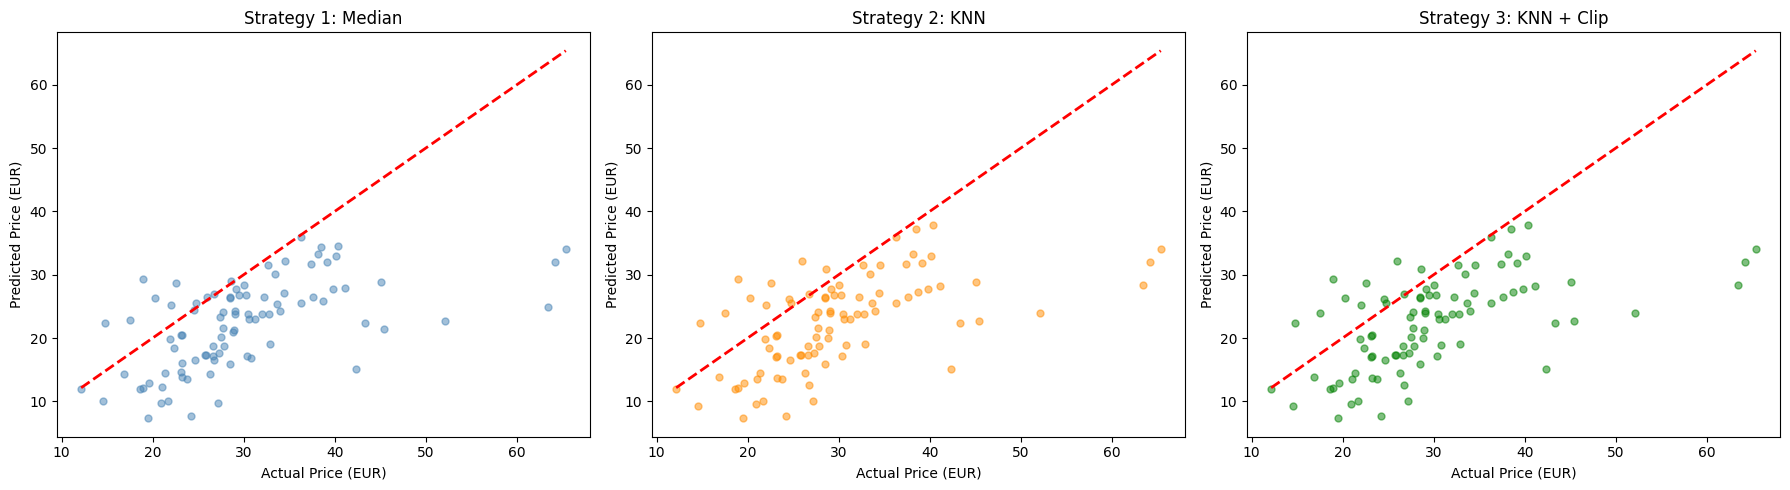

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

strategies = [
    (y_s1, y_pred_s1, "Strategy 1: Median", "steelblue"),
    (y_s2, y_pred_s2, "Strategy 2: KNN", "darkorange"),
    (y_s3, y_pred_s3, "Strategy 3: KNN + Clip", "green"),
]

for ax, (y_true, y_p, title, color) in zip(axes, strategies):
    ax.scatter(y_true, y_p, alpha=0.5, s=25, color=color)
    ax.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()],
            color="red", linestyle="--", linewidth=2)
    ax.set_xlabel("Actual Price (EUR)")
    ax.set_ylabel("Predicted Price (EUR)")
    ax.set_title(title)

plt.tight_layout()
plt.show()


## Step 7 – Final Comparison Table


In [19]:
comparison = pd.DataFrame({
    "Strategy": [
        "Internal Test",
        "Stress: Median (baseline)",
        "Stress: KNN Imputation",
        "Stress: KNN + Outlier Clip",
    ],
    "MAE (EUR)": [
        f"{mae_test:.2f}",
        f"{mae_s1:.2f}",
        f"{mae_s2:.2f}",
        f"{mae_s3:.2f}",
    ],
    "RMSE (EUR)": [
        f"{rmse_test:.2f}",
        f"{rmse_s1:.2f}",
        f"{rmse_s2:.2f}",
        f"{rmse_s3:.2f}",
    ],
    "R²": [
        f"{r2_test:.4f}",
        f"{r2_s1:.4f}",
        f"{r2_s2:.4f}",
        f"{r2_s3:.4f}",
    ],
})

print(comparison.to_string(index=False))

# Highlight best stress strategy
stress_r2s = {"Median": r2_s1, "KNN": r2_s2, "KNN + Clip": r2_s3}
best = max(stress_r2s, key=stress_r2s.get)
print(f"Best stress-test strategy: {best} (R² = {stress_r2s[best]:.4f})")

print("--- Done! ---")


                  Strategy MAE (EUR) RMSE (EUR)      R²
             Internal Test      1.80       2.25  0.9249
 Stress: Median (baseline)      8.68      11.33 -0.3288
    Stress: KNN Imputation      8.64      11.12 -0.2806
Stress: KNN + Outlier Clip      8.64      11.12 -0.2806
Best stress-test strategy: KNN + Clip (R² = -0.2806)
--- Done! ---


Next time we do  train a model with stress test data and than use log(price)